##Install Required Libraries

In [ ]:
!pip install -q \
  transformers==4.40.0 \
  peft==0.10.0 \
  accelerate \
  datasets==2.19.1 \
  scikit-learn==1.4.2 \
  sentence-transformers \
  umap-learn \
  gcsfs

!pip install numpy==1.26.4 --force-reinstall --no-cache-dir


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.3/245.3 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88

##Upload and Load JSON Dataset

In [1]:
import pandas as pd
import json
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

with open(filename, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df.head()


KeyboardInterrupt: 

##Cleaning

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[\n\r\t]", " ", text)
    text = re.sub(r"[\"']", "", text)
    text = re.sub(r"[^a-z0-9 ,.\[\]()/\-:]", "", text)
    text = re.sub(r"\.{2,}", ".", text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[,/]+", ",", text)
    text = re.sub(r"(,\s*,)+", ",", text)
    text = re.sub(r"(,\s*$)|(^\s*,)", "", text)
    text = re.sub(r"\b(p\s*,\s*p\s*,\s*c)\b", "ppc", text)
    return text.strip()


##Clean verdicts

In [ ]:
df["verdict"] = df["verdict"].apply(clean_text)
print("Unique cleaned verdicts:", df["verdict"].unique())


Unique cleaned verdicts: ['dismissed' 'transferred' 'allowed' 'acquitted' 'granted' 'remanded'
 'modified' 'upheld' 'maintainable' 'disposed' 'accepted' 'convicted'
 'disposed of' 'abated' 'partially allowed'
 'allowed (impugned order set aside)']


##Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder


label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["verdict"])
label_mapping = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))

df["label_name"] = df["label"].map(label_mapping)




##Show All Class Distribution

/tmp/ipython-input-5-2592332826.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label_name", palette="Set3", order=df["label_name"].value_counts().index)


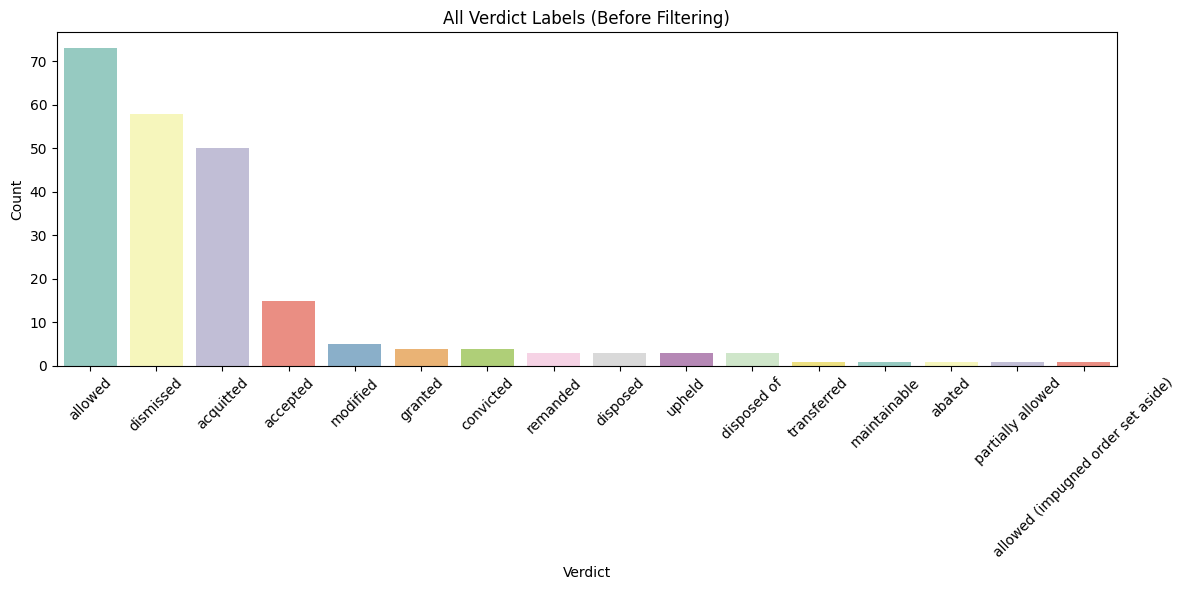

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="label_name", palette="Set3", order=df["label_name"].value_counts().index)
plt.title("All Verdict Labels (Before Filtering)")
plt.xlabel("Verdict")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##Filter Labels < 10

In [ ]:
label_counts = df["label"].value_counts()
valid_labels = label_counts[label_counts >= 10].index.tolist()
df = df[df["label"].isin(valid_labels)].reset_index(drop=True)

print("Kept Label to Verdict Mapping:")
for label in sorted(valid_labels):
    print(f"{label}: {label_mapping[label]}")

print("\nLabel distribution after filtering:")
print(df["label"].value_counts())


Kept Label to Verdict Mapping:
1: accepted
2: acquitted
3: allowed
6: dismissed

Label distribution after filtering:
label
3    73
6    58
2    50
1    15
Name: count, dtype: int64


##Histogram of Filtered Verdicts

/tmp/ipython-input-7-1387753426.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label_name", palette="Set2")


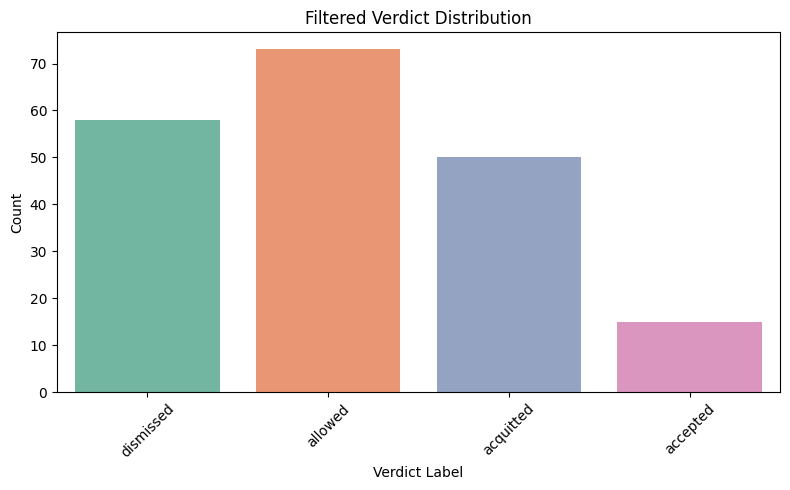

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="label_name", palette="Set2")
plt.title("Filtered Verdict Distribution")
plt.xlabel("Verdict Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Format BERT Input Text

In [ ]:
def format_case(row):
    summary = clean_text(row["summary"])
    pet = clean_text(row["petitioner_argument"])
    resp = clean_text(row["respondent_argument"])
    case_type = clean_text(row.get("case_type", ""))
    sections = clean_text(", ".join(row.get("offence_sections", [])))
    return f"[SUMMARY] {summary} [PETITIONER] {pet} [RESPONDENT] {resp} [CASE TYPE] {case_type} [SECTIONS] {sections}"

##Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split
from datasets import Dataset

train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

train_df["text"] = train_df.apply(format_case, axis=1)
val_df["text"] = val_df.apply(format_case, axis=1)

train_ds = Dataset.from_pandas(train_df[["text", "label"]])
val_ds = Dataset.from_pandas(val_df[["text", "label"]])

print("Train sample:\n", train_ds[0])

Train sample:
 {'text': '[SUMMARY] the petitioner sought confirmation of ad interim pre-arrest bail in a case involving allegations of criminal breach of trust under section 406 ppc. the court found that the dispute primarily pertained to civil liability and noted the existence of ongoing civil litigation between the parties, which raised concerns about malafide intent and false implication. the court confirmed the pre-arrest bail, emphasizing that no useful purpose would be served by arresting the petitioner. [PETITIONER] the dispute is civil in nature, and the fir was registered as a counterblast to ongoing civil litigation. [RESPONDENT] opposed the petitioners contention without specific grounds. [CASE TYPE] prearrestbail [SECTIONS] s, e, c, t, i, o, n, 4, 0, 6, ppc', 'label': 3, '__index_level_0__': 24}


##Tokenize Data

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("nlpaueb/legal-bert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

tokenized_train_ds = train_ds.map(tokenize, batched=True)
tokenized_val_ds = val_ds.map(tokenize, batched=True)

cols_to_remove = [col for col in tokenized_train_ds.column_names if col.startswith("__")]
tokenized_train_ds = tokenized_train_ds.remove_columns(cols_to_remove)
tokenized_val_ds = tokenized_val_ds.remove_columns(cols_to_remove)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/156 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

##Load Model

In [ ]:
num_labels = df["label"].max() + 1
print("Number of unique labels (num_labels):", num_labels)

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "nlpaueb/legal-bert-base-uncased",
    num_labels=num_labels
)


Number of unique labels (num_labels): 7


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/legal-bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


##Training Setup

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=30,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)


##Initialize Trainer

In [ ]:
from transformers import Trainer, DataCollatorWithPadding
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_ds,
    eval_dataset=tokenized_val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

##Train

In [ ]:
from transformers import Trainer



trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.059700,0.880390,0.675000,0.621429,0.675000,0.641954
2,0.955100,0.968536,0.500000,0.463889,0.500000,0.458571
3,0.820500,0.794852,0.650000,0.586688,0.650000,0.605119
4,0.770600,1.053268,0.600000,0.711308,0.600000,0.500221
5,0.695200,0.671271,0.775000,0.767308,0.775000,0.738641
6,0.466700,0.747491,0.725000,0.793831,0.725000,0.745055
7,0.486100,0.791804,0.775000,0.769019,0.775000,0.746544
8,0.284400,0.678272,0.800000,0.750219,0.800000,0.763999
9,0.311000,0.385423,0.875000,0.891154,0.875000,0.877715
10,0.301700,0.423932,0.900000,0.916964,0.900000,0.903188


TrainOutput(global_step=600, training_loss=0.2510809496976435, metrics={'train_runtime': 1408.4436, 'train_samples_per_second': 3.323, 'train_steps_per_second': 0.426, 'total_flos': 1231415018496000.0, 'train_loss': 0.2510809496976435, 'epoch': 30.0})

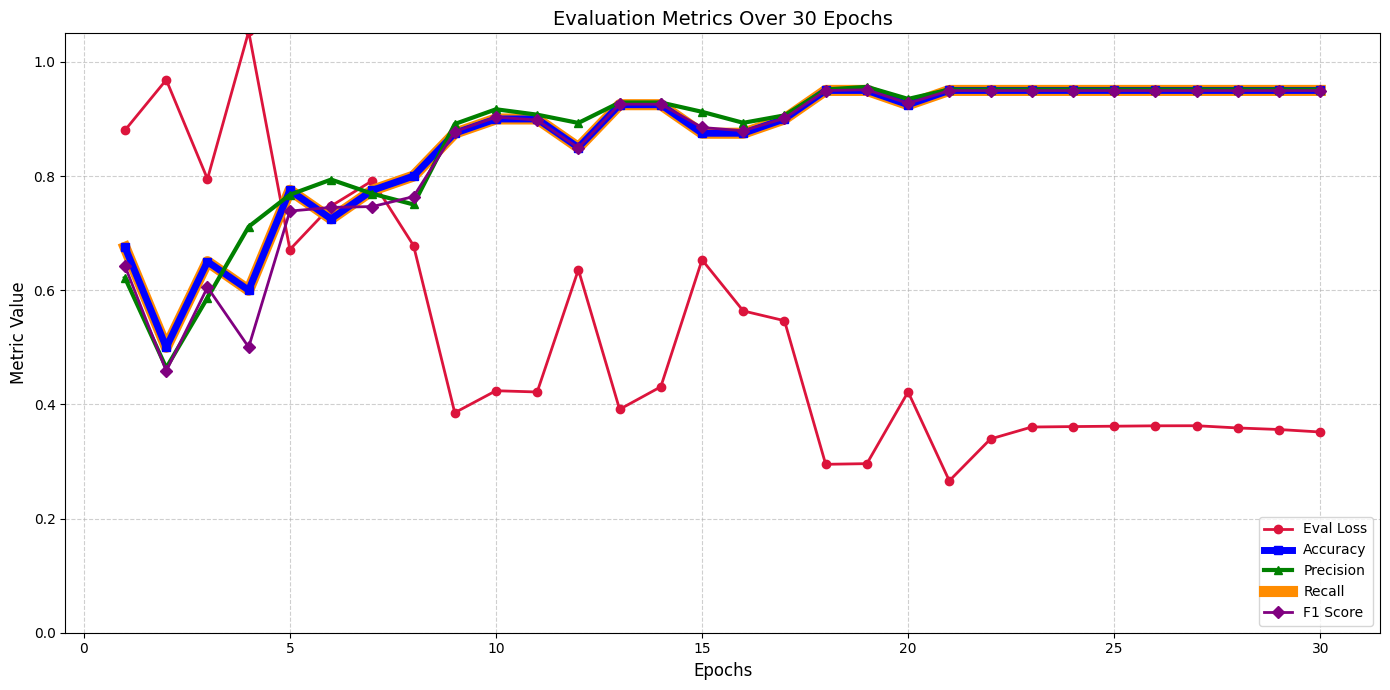

In [ ]:
import os
import json
import matplotlib.pyplot as plt

#Auto-detect latest checkpoint
checkpoint_dirs = [ckpt for ckpt in os.listdir("./results") if ckpt.startswith("checkpoint")]
latest_ckpt = sorted(checkpoint_dirs, key=lambda x: int(x.split("-")[-1]))[-1]
trainer_state_path = f"./results/{latest_ckpt}/trainer_state.json"

#Load trainer_state.json
with open(trainer_state_path, "r") as f:
    logs = json.load(f)

#Extract metrics
log_history = logs["log_history"]
epochs, eval_loss, eval_accuracy, eval_precision, eval_recall, eval_f1 = [], [], [], [], [], []

for entry in log_history:
    if "eval_loss" in entry:
        epochs.append(entry["epoch"])
        eval_loss.append(entry.get("eval_loss"))
        eval_accuracy.append(entry.get("eval_accuracy"))
        eval_precision.append(entry.get("eval_precision"))
        eval_recall.append(entry.get("eval_recall"))
        eval_f1.append(entry.get("eval_f1"))


plt.figure(figsize=(14, 7))

plt.plot(epochs, eval_loss, label="Eval Loss", marker='o', linewidth=2, color='crimson', zorder=2)
plt.plot(epochs, eval_accuracy, label="Accuracy", marker='s', linewidth=5, color='blue', zorder=5)
plt.plot(epochs, eval_precision, label="Precision", marker='^', linewidth=3, color='green', zorder=5)
plt.plot(epochs, eval_recall, label="Recall", marker='v', linewidth=8, color='darkorange', zorder=4)
plt.plot(epochs, eval_f1, label="F1 Score", marker='D', linewidth=2, color='purple', zorder=6)

plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Metric Value", fontsize=12)
plt.title("Evaluation Metrics Over 30 Epochs", fontsize=14)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
print("Epochs:", len(epochs))
print("Accuracy:", len(eval_accuracy))
print("Loss:", len(eval_loss))
print("Precision:", len(eval_precision))
print("Recall:", len(eval_recall))
print("F1:", len(eval_f1))


Epochs: 30
Accuracy: 30
Loss: 30
Precision: 30
Recall: 30
F1: 30


In [ ]:
trainer.save_model("./best_epoch18_model")
tokenizer.save_pretrained("./best_epoch18_model")


('./best_epoch18_model/tokenizer_config.json',
 './best_epoch18_model/special_tokens_map.json',
 './best_epoch18_model/vocab.txt',
 './best_epoch18_model/added_tokens.json',
 './best_epoch18_model/tokenizer.json')

In [ ]:
trainer.save_model("./best_epoch18_model")


In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model = AutoModelForSequenceClassification.from_pretrained("./best_epoch18_model")
tokenizer = AutoTokenizer.from_pretrained("./best_epoch18_model")



In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

#Loading best model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained("./best_epoch18_model")
tokenizer = AutoTokenizer.from_pretrained("./best_epoch18_model")

#Define metrics function
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

#Create a Trainer only for evaluation
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=data_collator,
    eval_dataset=tokenized_val_ds,
    compute_metrics=compute_metrics
)

#Evaluate the model
metrics = trainer.evaluate()

#Display results
print("\nEvaluation results for Epoch 18:")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")



Evaluation results for Epoch 18:
eval_loss: 0.2950
eval_accuracy: 0.9500
eval_precision: 0.9516
eval_recall: 0.9500
eval_f1: 0.9497
eval_runtime: 1.3452
eval_samples_per_second: 29.7360
eval_steps_per_second: 3.7170


##Interference

In [ ]:
#Import Required Libraries
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from sklearn.preprocessing import LabelEncoder
import torch
import re

#Load Trained Model & Tokenizer
model_path = "./best_epoch18_model"

model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)
model.eval()


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

##Define Text Cleaning Function (Same as Training)

In [ ]:
#Clean & Format Input Case
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[\n\r\t]", " ", text)
    text = re.sub(r"[\"']", "", text)
    text = re.sub(r"[^a-z0-9 ,.\[\]()/\-:]", "", text)
    text = re.sub(r"\.{2,}", ".", text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[,/]+", ",", text)
    text = re.sub(r"(,\s*,)+", ",", text)
    text = re.sub(r"(,\s*$)|(^\s*,)", "", text)
    text = re.sub(r"\b(p\s*,\s*p\s*,\s*c)\b", "ppc", text)
    return text.strip()

def format_case(case):
    summary = clean_text(case["summary"])
    pet = clean_text(case["petitioner_argument"])
    resp = clean_text(case["respondent_argument"])
    case_type = clean_text(case.get("case_type", ""))
    sections = clean_text(", ".join(case.get("offence_sections", [])))

    return f"[SUMMARY] {summary} [PETITIONER] {pet} [RESPONDENT] {resp} [CASE TYPE] {case_type} [SECTIONS] {sections}"


In [ ]:
#Label Mapping (Restore Original Labels)

label_encoder = LabelEncoder()
label_encoder.fit(df["verdict"])
label_mapping = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))


##Define Prediction Function

In [ ]:
def predict_verdict(case, model, tokenizer, label_mapping):
    formatted_text = format_case(case)


    inputs = tokenizer(
        formatted_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

#Get predictions
    with torch.no_grad():
        outputs = model(**inputs)
        predicted_label = torch.argmax(outputs.logits, dim=1).item()

    return label_mapping[predicted_label]


In [ ]:
#Example Usage

sample_case = {
    "summary": "The appellant was convicted under Section 489-F PPC for issuing a dishonored cheque.",
    "petitioner_argument": "The petitioner claims the cheque was post-dated and not meant for encashment.",
    "respondent_argument": "The respondent asserts that the cheque was given as repayment of a loan and knowingly bounced.",
    "case_type": "Criminal Appeal"
}



predicted_verdict = predict_verdict(sample_case, model, tokenizer, label_mapping)
print("Predicted Verdict:", predicted_verdict)


Predicted Verdict: acquitted


In [ ]:
!zip -r best_epoch18_model.zip best_epoch18_model


  adding: best_epoch18_model/ (stored 0%)
  adding: best_epoch18_model/special_tokens_map.json (deflated 42%)
  adding: best_epoch18_model/model.safetensors (deflated 7%)
  adding: best_epoch18_model/config.json (deflated 56%)
  adding: best_epoch18_model/training_args.bin (deflated 51%)
  adding: best_epoch18_model/tokenizer.json (deflated 71%)
  adding: best_epoch18_model/vocab.txt (deflated 51%)
  adding: best_epoch18_model/tokenizer_config.json (deflated 75%)


In [ ]:
from google.colab import files
files.download("best_epoch18_model.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.savefig("eval_metrics_plot.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
from google.colab import files
files.download("eval_metrics_plot.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

# List the files in the specified directory
directory_path = "./best_epoch18_model"
if os.path.exists(directory_path):
    print(f"Files in {directory_path}:")
    for filename in os.listdir(directory_path):
        print(filename)
else:
    print(f"Directory not found: {directory_path}")

Files in ./best_epoch7_model:
config.json
special_tokens_map.json
tokenizer.json
training_args.bin
tokenizer_config.json
vocab.txt
model.safetensors
